<div align='center'>
    <h1>Jurnal Praktikum Dasar Kecerdasan Artifisial</h1>
    <h3>Modul 14: Implementasi A*</h3>
</div>

### Tujuan Praktikum
- Mahasiswa mampu memahami dan mengimplementasikan algoritma A* pada Python dengan menggunakan *library* NetworkX.

**Jangan lupa untuk selalu import *library* NetworkX ketika memulai sesi baru (run time) atau kode Python yang memerlukan penggunaan *library* NetworkX.**

### Import *Library* NetworkX dan Matplotlib

*Library* Matplotlib digunakan untuk membantu menampilkan visualisasi graf pada terminal.

In [1]:
print("'Aarif Rahmaan Jalaluddin Faqiih")  # Tuliskan nama lengkap Anda
print("103112430182")  # Tuliskan NIM Anda
print("IF-12-06")  # Tuliskan kelas Anda
print("https://colab.research.google.com/drive/1t625KthWO3qfLr2Q08NmE3nKPIeoEyzg?usp=sharing") # Link collab Praktikum
print("https://colab.research.google.com/drive/1nqxzx0uk2L59t55tZjWv6m07fkvA_HQy?usp=sharing") # Link collab Jurnal
print("https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/MODUL%2011")

'Aarif Rahmaan Jalaluddin Faqiih
103112430182
IF-12-06
https://colab.research.google.com/drive/1t625KthWO3qfLr2Q08NmE3nKPIeoEyzg?usp=sharing
https://colab.research.google.com/drive/1nqxzx0uk2L59t55tZjWv6m07fkvA_HQy?usp=sharing
https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/MODUL%2011


In [2]:
import networkx as nx # Library untuk membuat graf
import matplotlib.pyplot as plt # Library untuk visualisasi

### Fungsi pendukung untuk mencetak graf

#### **!! Tidak usah dimodifikasi !!**

In [3]:
# Posisi Nodes
pos = {
    'Entrance': (0, 0),
    'Library': (5, 5),
    'Cafeteria': (5, 0),
    'Gym': (0, 5),
    'Cacuk': (2, 3),
    'GKU': (3, 2),
    'Lab': (4, 4)
}

In [4]:
# Fungsi pendukung untuk mencetak graf
def show_graph(G, pos=None, title='') :
  # Membuat pos jika pos tidak diberikan
  if pos is None:
      pos = nx.spring_layout(G)

  # Fungsi untuk menggambar node
  nx.draw(
      G,                  # Graf NetworkX
      pos,                # Posisi node
      with_labels=True,   # Menampilkan nama node
      node_color='red',   # Warna node
      node_size=2500,     # Ukuran node
      font_color="white", # Warna font label node
      font_size=12,
      width=5             # Ketebalan garis edge
  )

  # Mengambil label edge jika ada weight
  edge_labels = nx.get_edge_attributes(G, 'weight')
  # Fungsi untuk menggambar node
  nx.draw_networkx_edge_labels(
      G,
      pos,
      edge_labels=edge_labels, # Data weight
      font_color='blue',       # Warna font label edge
      font_size=12,            # Ukuran font label edge
  )

  plt.margins(0.2)  # Memberikan margin pada plot
  plt.title(title)  # Menampilkan judul graf jika diberikan
  plt.show()

### 1. Implementasi A* *Weighted Undirected Graph* (40 poin)

Di sebuah universitas terdapat beberapa gedung yang terhubung dengan jalan setapak. Setiap gedung memiliki nama dan jarak tertentu satu sama lain. Di kampus tersebut, seorang mahasiswa ingin menuju ke perpustakaan, tetapi ia ingin menggunakan jalur terpendek untuk sampai ke sana. Mahasiswa tersebut memulai perjalannya dari pintu masuk utama.

Setiap gedung memiliki informasi jarak gedung-gedung lainnya yang terhubung langsung. Bantu mahasiswa menemukan `Library` dengan algoritma A* Search dengan melakukan langkah-langkah berikut.

**a. (5 poin)** Inisialisasi graf bernama `universitas` menggunakan **graf tidak berarh**.

In [5]:
# Inisialisasi graf tidak berarah
universitas = nx.Graph()

**b. (5 poin)** Tambahkan node untuk merepresentasikan setiap gedung di universitas tersebut. Nama gedung adalah sebagai berikut :
- `Entrance`
- `Library`
- `Cafeteria`
- `Gym`
- `Cacuk`
- `GKU`
- `Lab`

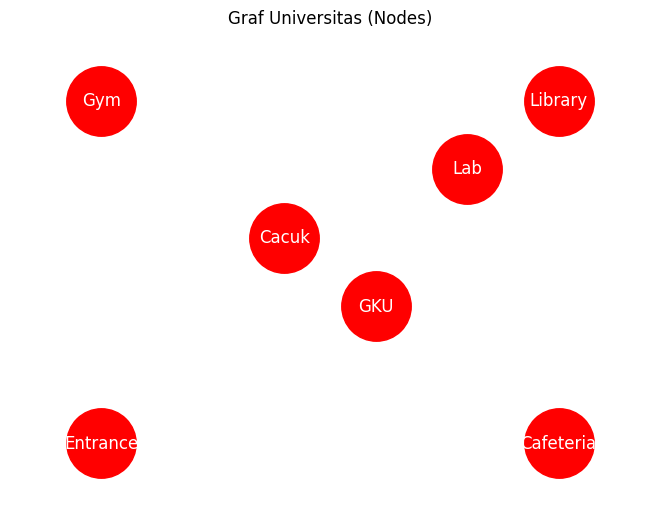

In [6]:
# List daftar nama gedung di dalam kampus universitas
nodes = ['Entrance', 'Library', 'Cafeteria', 'Gym', 'Cacuk', 'GKU', 'Lab']

# Tambahkan node dari list `nodes` pada graf kampus_universitas
universitas.add_nodes_from(nodes)

# Tampilkan graf kampus_universitas setelah penambahan node
show_graph(universitas, pos, title='Graf Universitas (Nodes)')

Contoh *output*:

![Add Nodes Universitas](./asset/1_add_nodes_universitas.png)

**c. (10 poin)** Berikut adalah jarak antar gedung pada universitas

- `Entrance` ke `Cacuk` -> 300m
- `Entrance` ke `Cafetaria` -> 150m
- `Cafetaria` ke `GKU` -> 200m
- `Cacuk` ke `Lab` -> 100m
- `GKU` ke `Lab` -> 150m
- `Gym` ke `Library` -> 400m
- `Gym` ke `Lab` -> 200m

Tambahkan informasi jarak antar wahana sebagai edge pada graf `universitas`

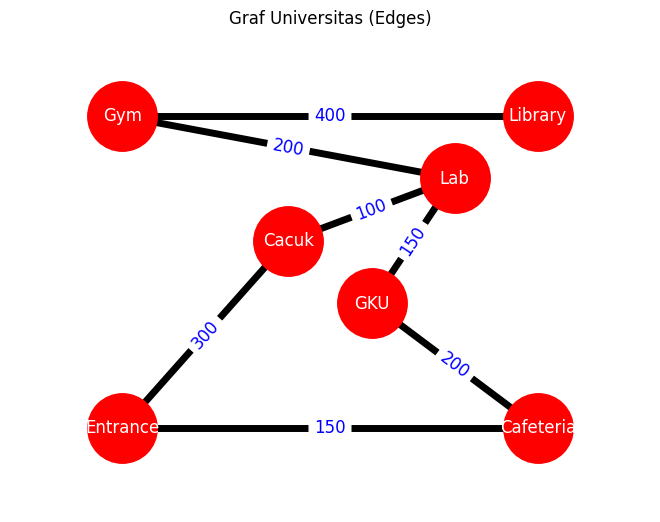

In [7]:
# Daftar jarak antara dua gedung pada universitas
edges = [
    ('Entrance', 'Cacuk', 300),
    ('Entrance', 'Cafeteria', 150),
    ('Cafeteria', 'GKU', 200),
    ('Cacuk', 'Lab', 100),
    ('GKU', 'Lab', 150),
    ('Gym', 'Library', 400),
    ('Gym', 'Lab', 200)
]

# Tambahkan jarak yang menghubungkan antara dua gedung dalam graf universitas
universitas.add_weighted_edges_from(edges)

# Tampilkan graf universitas setelah penambahan edge
show_graph(universitas, pos, title='Graf Universitas (Edges)')


Contoh *output*:

![Add edges Universitas](./asset/2_add_edges_universitas.png)

**d. (5 poin)** Sekarang, evaluasi elemen pada graf `universitas` yang sudah dibuat. Tampilkan hal berikut:
- Daftar gedung pada graf yang diwakili oleh node.
- Daftar gedung apa saja yang terhubung yang diwakili oleh edge.
- Jumlah gedung pada graf.

In [8]:
print("Elemen pada Graf:\n")

# Mencetak daftar node pada graf
print(f"Gedung yang terdapat di universitas: {list(universitas.nodes)}")

# Mencetak daftar edge pada graf
print(f"Daftar gedung yang terhubung: {list(universitas.edges)}")

# Mencetak jumlah node
print(f"Jumlah gedung pada universitas: {universitas.number_of_nodes()}")


Elemen pada Graf:

Gedung yang terdapat di universitas: ['Entrance', 'Library', 'Cafeteria', 'Gym', 'Cacuk', 'GKU', 'Lab']
Daftar gedung yang terhubung: [('Entrance', 'Cacuk'), ('Entrance', 'Cafeteria'), ('Library', 'Gym'), ('Cafeteria', 'GKU'), ('Gym', 'Lab'), ('Cacuk', 'Lab'), ('GKU', 'Lab')]
Jumlah gedung pada universitas: 7


Contoh *output*:

Elemen pada Graf:

Gedung yang terdapat di universitas: ['Entrance', 'Library', 'Cafeteria', 'Gym', 'Cacuk', 'GKU', 'Lab']

Daftar gedung yang terhubung: [('Entrance', 'Cacuk'), ('Entrance', 'Cafeteria'), ('Library', 'Gym'), ('Cafeteria', 'GKU'), ('Gym', 'Lab'), ('Cacuk', 'Lab'), ('GKU', 'Lab')]

Jumlah gedung pada universitas: 7

**e. (10 poin)** Membuat fungsi heursitik.

Fungsi heuristik digunakan untuk memperkirakan jarak yang harus ditempuh dari suatu node ke tujuan akhir. Algoritma A* akan memilih node berdasarkan nilai f(n) = g(n) + h(n), di mana g(n) adalah jarak yang sudah ditempuh dan h(n) adalah nilai heuristik.

Berikut adalah nilai heuristik setiap wahana yang terdapat pada graf `universitas`:
|Nama Gedung|Nilai Heuristik|
|-----------|---------------|
|Entrance|400m|
|Cafetaria|300m|
|Cacuk|200m|
|GKU|250m|
|Gym|500m|
|Lab|100m|
|Library|0m|

Buat fungsi untuk menghitung nilai heuristik dengan nama `heuristable()`

In [9]:
# Fungsi untuk menghitung nilai heuristik setiap node
heuristics_univ = {
    'Entrance': 400,
    'Cafeteria': 300,
    'Cacuk': 200,
    'GKU': 250,
    'Gym': 500,
    'Lab': 100,
    'Library': 0
}

def heuristable(u, v):
    return heuristics_univ.get(u, 0)

**f. (5 poin)** Sekarang, tentukan jalur yang dilewati dari `Entrance` ke `Library` menggunakan algoritma A* dan tampilkan urutan gedung yang dikunjungi serta jarak yang ditempuh berdasarkan masukan dari pengguna.

Tip :
Gunakan bantuan function `nx_astar_path()`

In [10]:
# Menerima input lokasi awal dan tujuan dari pengguna
awal = input("Masukkan lokasi awal: ")
tujuan = input("Masukkan lokasi tujuan: ")

# Mencari node yang dikunjungi dari awal ke tujuan menggunakan algoritma A*
jalur = nx.astar_path(universitas, awal, tujuan, heuristic=heuristable, weight='weight')

# Menghitung jarak yang ditempuh dari awal ke tujuan
jarak = nx.astar_path_length(universitas, awal, tujuan, heuristic=heuristable, weight='weight')

# Cetak hasil
print(f"\nGedung yang dikunjungi dari `{awal}` ke `{tujuan}` adalah: {jalur}")
print(f"Jarak yang ditempuh dari `{awal}` ke `{tujuan}` sejauh: {jarak} meter")

Masukkan lokasi awal: Entrance
Masukkan lokasi tujuan: Library

Gedung yang dikunjungi dari `Entrance` ke `Library` adalah: ['Entrance', 'Cacuk', 'Lab', 'Gym', 'Library']
Jarak yang ditempuh dari `Entrance` ke `Library` sejauh: 1000 meter


Contoh *output*:

Masukkan lokasi awal: `Entrance`

Masukkan lokasi tujuan: `Library`

Gedung yang dikunjungi dari `Entrance` ke `Library` adalah: ['Entrance', 'Cacuk', 'Lab', 'Gym', 'Library']

Jarak yang ditempuh dari `Entrance` ke `Library` sejauh: 1000 meter

### 2. Implementasi A* pada Weighted Directed Graph (60 poin)

DI sebuah kota metropolitan terdapat sistem transportasi umum berupa jalur bus yang terhubung dengan beberapa terminal. Setiap terminal memiliki nama dan jarak tertentu satu sama lain. Di kota tersebut, seorang pekerja ingin menuju ke kantor pusat perusahaan, tetapi ia ingin menggunakan jalur tercepat untuk sampai kesana. Pekerja tersebut memulai perjalanannya dari terminal utama.

Bantu pekerja tersebut untuk menemukan `Kantor Pusat` dengan algoritma A* Search dengan melakukan langkah-langkah berikut.

### Fungsi pendukung untuk mencetak graf

#### **!! Tidak usah dimodifikasi !!**

In [11]:
# Posisi node
pos = {
    'Main Terminal': (0, 0),
    'Central Park': (2, 3),
    'Downtown': (3, 1),
    'Uptown': (1, -2),
    'East Side': (4, 4),
    'West End': (5, -1),
    'Kantor Pusat': (6, 2)
}

In [12]:
# Fungsi pendukung untuk mencetak graf
def show_graph(G, pos=None, title='') :
  # Membuat pos jika pos tidak diberikan
  if pos is None:
      pos = nx.spring_layout(G)

  # Fungsi untuk menggambar node
  nx.draw(
      G,                  # Graf NetworkX
      pos,                # Posisi node
      with_labels=True,   # Menampilkan nama node
      node_color='red',   # Warna node
      node_size=4000,     # Ukuran node
      font_color="white", # Warna font label node
      font_size=10,
      width=5             # Ketebalan garis edge
  )

  # Mengambil label edge jika ada weight
  edge_labels = nx.get_edge_attributes(G, 'weight')
  # Fungsi untuk menggambar node
  nx.draw_networkx_edge_labels(
      G,
      pos,
      edge_labels=edge_labels, # Data weight
      font_color='blue',       # Warna font label edge
      font_size=10,            # Ukuran font label edge
  )

  plt.margins(0.2)  # Memberikan margin pada plot
  plt.title(title)  # Menampilkan judul graf jika diberikan
  plt.show()

**a. (10 poin)** Inisialisasi graf berarah bernama `kota_metropolitan` untuk menampung informasi pameran beserta jarak antara pameran tersebut.

In [13]:
# Inisialisasi graf berarah
kota_metropolitan = nx.DiGraph()

**b. (10 poin)** Pada galeri seni, seluruh pengunjung mulai dari pintu masuk yang kemudian terdapat beberapa pameran dari berbagai seniman dengan daftar sebagai berikut:

- `Main Terminal`
- `Central Park`
- `Downtown`
- `Uptown`
- `East Side`
- `West End`
- `Kantor Pusat`

Tambahkan terminal utama dan seluruh terminal tersebut ke dalam graf yang sudah dibuat, kemudian tampilkan hasil graf yang sudah terdapat seluruh terminal pada sistem transportasi kota.

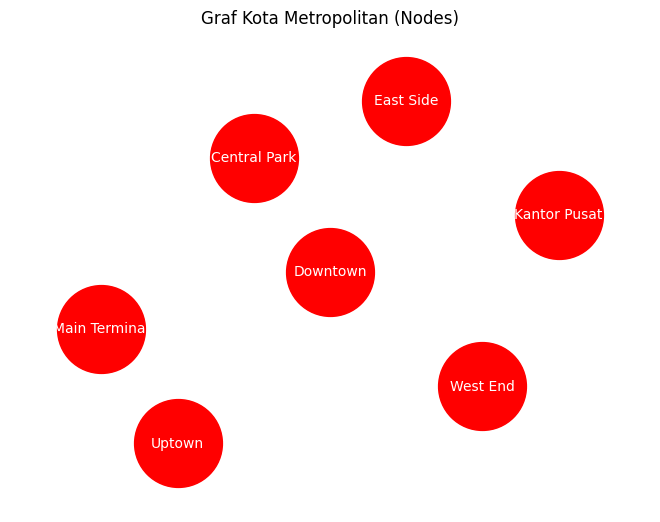

In [14]:
# List nama terminal pada sistem transportasi kota
nodes_kota = ['Main Terminal', 'Central Park', 'Downtown', 'Uptown', 'East Side', 'West End', 'Kantor Pusat']

# Tambahkan node dari daftar terminal yang terdapat pada sistem transportasi kota
kota_metropolitan.add_nodes_from(nodes_kota)

# Tampilkan graf kota_metropolitan setelah penambahan node
show_graph(kota_metropolitan, pos, title='Graf Kota Metropolitan (Nodes)')

Contoh *output*:

![Add Nodes Kota Metropolitan](./asset/3_add_nodes_kota_metropolitan.png)

**c. (15 poin)** Berikut adalah jarak dari setiap terminal pada sistem transportasi kota

- **Main Terminal** ke **Central Park** memiliki jarak sejauh 300m.
- **Main Terminal** ke **Downtown** memiliki jarak sejauh 400m.
- **Central Park** ke **East Side** memiliki jarak sejauh 250m.
- **Downtown** ke **Uptown** memiliki jarak sejauh 350m.
- **Downtown** ke **West End** memiliki jarak sejauh 200m.
- **East Side** ke **Kantor Pusat** memiliki jarak sejauh 150m.
- **West End** ke **Kantor Pusat** memiliki jarak sejauh 100m.

Tambahkan data jarak tersebut ke dalam graf `kota_metropolitan`, kemudian tampilkan graf setelah ditambahkan jarak.

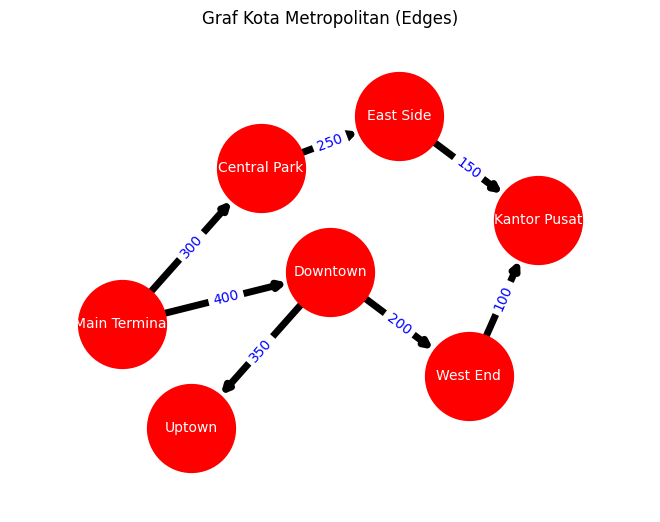

In [15]:
# Daftar jarak antara dua terminal pada sistem transportasi kota
edges_kota = [
    ('Main Terminal', 'Central Park', 300),
    ('Main Terminal', 'Downtown', 400),
    ('Central Park', 'East Side', 250),
    ('Downtown', 'Uptown', 350),
    ('Downtown', 'West End', 200),
    ('East Side', 'Kantor Pusat', 150),
    ('West End', 'Kantor Pusat', 100)
]

# Tambahkan jarak yang menghubungkan antara dua terminal
kota_metropolitan.add_weighted_edges_from(edges_kota)

# Tampilkan graf kota_metropolitan setelah penambahan edges
show_graph(kota_metropolitan, pos, title='Graf Kota Metropolitan (Edges)')


Contoh *output* :

![Add Edges Kota Metropolitan](./asset/4_add_edges_kota_metropolitan.png)

**d. (10 poin)** Buat fungsi heuristik bernama `heuristable()` untuk menghitung nilai heuristik dari setiap lokasi pameran dengan nilai heuristik berikut:

|Nama Tempat|Nilai Heuristik|
|-----------|---------------|
|Main Terminal|500m|
|Central Park   |350m|
|Downtown    |400m|
|Uptown      |300m|
|East Side   |200m|
|West End   |250m|
|Kantor Pusat|0m|

In [16]:
# Fungsi untuk menghitung nilai heuristik setiap node
heuristics_kota = {
    'Main Terminal': 500,
    'Central Park': 350,
    'Downtown': 400,
    'Uptown': 300,
    'East Side': 200,
    'West End': 250,
    'Kantor Pusat': 0
}

def heuristable_kota(u, v):
    return heuristics_kota.get(u, 0)

**e. (15 poin)** Sekarang tentukan jalur yang dilewati dari `Main Terminal` ke `Kantor Pusat` menggunakan algoritma A* yang memanfaatkan fungsi `nx.astar_path()`. Kemudian tampilkan urutan terminal yang dikunjungi serta jarak yang ditempuh berdasarkan masukan dari pengguna.

In [17]:
# Menerima input lokasi awal dan tujuan dari pengguna
awal_kota = input("Masukkan lokasi awal: ")
tujuan_kota = input("Masukkan lokasi tujuan: ")

# Mencari node yang dikunjungi dari Main Terminal ke Kantor Pusat
jalur_kota = nx.astar_path(kota_metropolitan, awal_kota, tujuan_kota, heuristic=heuristable_kota, weight='weight')

# Menghitung jarak yang ditempuh dari Main Terminal ke Kantor Pusat
jarak_kota = nx.astar_path_length(kota_metropolitan, awal_kota, tujuan_kota, heuristic=heuristable_kota, weight='weight')

# Cetak hasil
print(f"\nTerminal yang dikunjungi dari `{awal_kota}` ke `{tujuan_kota}` adalah: {jalur_kota}")
print(f"Jarak yang ditempuh dari `{awal_kota}` ke `{tujuan_kota}` sejauh: {jarak_kota} meter")

Masukkan lokasi awal: Main Terminal
Masukkan lokasi tujuan: Kantor Pusat

Terminal yang dikunjungi dari `Main Terminal` ke `Kantor Pusat` adalah: ['Main Terminal', 'Central Park', 'East Side', 'Kantor Pusat']
Jarak yang ditempuh dari `Main Terminal` ke `Kantor Pusat` sejauh: 700 meter


Contoh *output*:

Masukkan lokasi awal: `Main Terminal`

Masukkan lokasi tujuan: `Kantor Pusat`

Terminal yang dikunjungi dari `Main Terminal` ke `Kantor Pusat` adalah: ['Main Terminal', 'Central Park', 'East Side', 'Kantor Pusat']

Jarak yang ditempuh dari `Main Terminal` ke `Kantor Pusat` sejauh: 700 meter